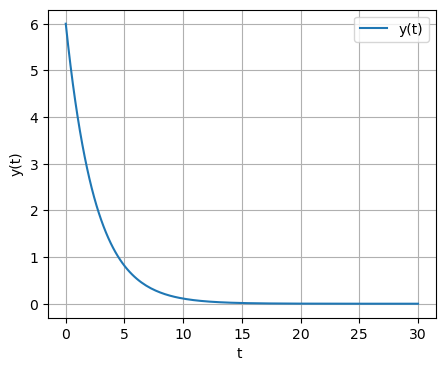

In [ ]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def model_func(t, y, k):
    dydt = - k * y 
    return dydt

# initial conditions
y0 = [6]

# time span
t_span = (0, 30)

# time points where the solution is evaluated
t_eval = np.linspace(t_span[0],
                     t_span[1],
                     150
                     )

# parameter
k = 0.4

# solve the ODE
sol = solve_ivp(model, 
                t_span,
                y0,
                args=(k,),
                t_eval=t_eval
                )

# plot
plt.figure(figsize=(5,4))
plt.plot(sol.t, sol.y[0], label='y(t)')
plt.xlabel('t ')
plt.ylabel('y(t)')
plt.grid(True)
plt.legend(loc='best')
plt.show()

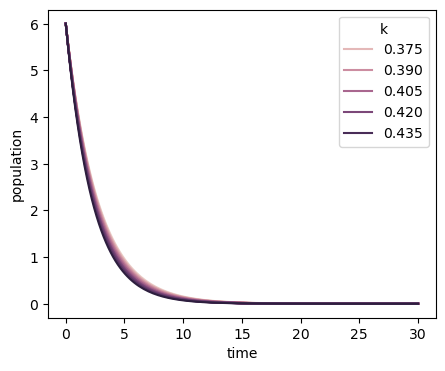

In [20]:
def create_df(result, columns, **other_info):
    df = pd.DataFrame(result, columns=columns)
    for key, value in other_info.items():
        df[key] = value
    return df

create_df(sol.y[0],
          ['population'],
          k=k,
          time=sol.t).head()

# randomly generate 50 normally distributed values of k
rates = np.random.normal(k, 0.02, 50)

results = []

for ri in rates:
    sol = solve_ivp(model, 
                    t_span,
                    y0,
                    args=(ri,),
                    t_eval=t_eval
                    )
    ys_df = create_df(sol.y[0],
                    ['population'],
                    k=ri,
                    time=sol.t)
    results.append(ys_df)
results = pd.concat(results, ignore_index=True)

plt.figure(figsize=(5,4))
sns.lineplot(x="time", y="population",
             data=results,
             hue="k",
             estimator=None)
plt.show()
